In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [2]:
df=pd.read_csv('train.csv')
#1. Fill missing age values with the median age
df['Age']=df['Age'].fillna(df['Age'].median())
#2. Fill missing embarked values with the most common port
most_common_port=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(most_common_port)
#3. Convert 'Sex' to numeric: female->1,male->0
df['IsFemale']=df['Sex'].map({'female':1,'male':0})
features=['Pclass','Age','Fare','SibSp','Parch','IsFemale']
x=df[features]
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)#stratify means have equal suvived and not survived in train and test 


In [3]:
#Decision tree model
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
train_acc=accuracy_score(y_train,model.predict(x_train))
test_acc=accuracy_score(y_test,model.predict(x_test))
tree_depth=model.get_depth()
n_leaves=model.get_n_leaves()
print("Unconstrained Decision Tree Results:")
print(f"Tree Depth : {tree_depth}")
print(f"Number of Leaves: {n_leaves}")
print(f"Train Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")#Huge gap between train and test accuracy due to overfitting

Unconstrained Decision Tree Results:
Tree Depth : 23
Number of Leaves: 161
Train Accuracy: 98.17%
Test Accuracy: 80.45%


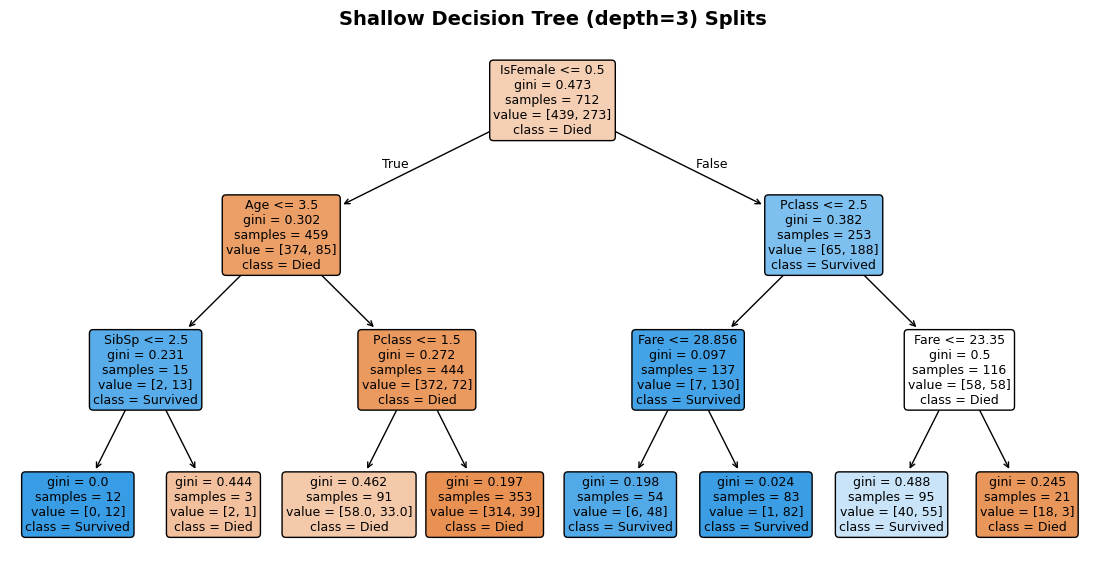

In [4]:
#Visualize the decision tree
df_shallow=DecisionTreeClassifier(max_depth=3,random_state=42)
df_shallow.fit(x_train,y_train)

plt.figure(figsize=(14,7))
plot_tree(df_shallow,feature_names=x.columns,class_names=['Died','Survived'],filled=True,rounded=True,fontsize=9)
plt.title("Shallow Decision Tree (depth=3) Splits",fontsize=14,fontweight='bold')
plt.show()

Optimal Depth by test Accuracy: 3 (Accuracy: 81.01%)


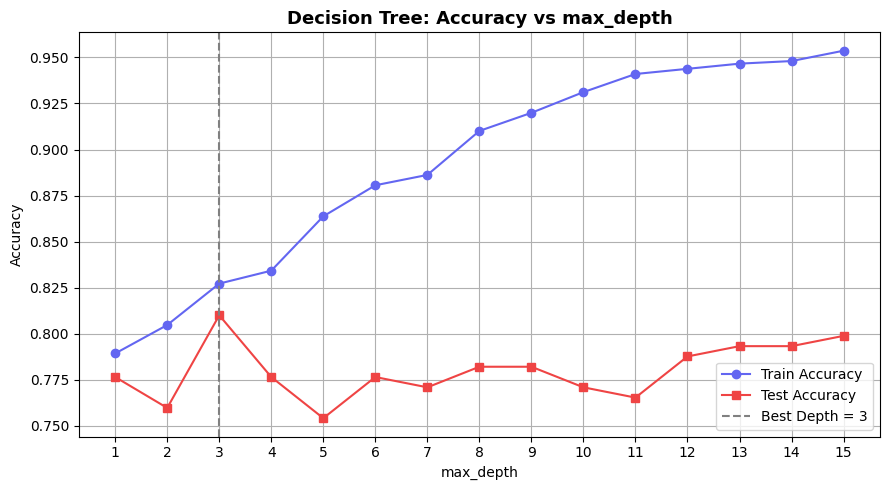

In [5]:
#Regularization- Tuning Tree Hyperparameters (To solve overfitting problem)
depths=range(1,16)
train_scores=[]
test_scores=[]

for d in depths:
    dt=DecisionTreeClassifier(max_depth=d,random_state=42)
    dt.fit(x_train,y_train)
    train_scores.append(accuracy_score(y_train,dt.predict(x_train)))
    test_scores.append(accuracy_score(y_test,dt.predict(x_test)))

best_depth=depths[np.argmax(test_scores)]
print(f"Optimal Depth by test Accuracy: {best_depth} (Accuracy: {max(test_scores):.2%})")

plt.figure(figsize=(9,5))
plt.plot(depths,train_scores,'o-',color='#6366f1',label='Train Accuracy')
plt.plot(depths,test_scores,'s-',color='#ef4444',label='Test Accuracy')
plt.axvline(best_depth,color='gray',linestyle='--',label=f'Best Depth = {best_depth}')
plt.title('Decision Tree: Accuracy vs max_depth',fontsize=13,fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
#Random Forests (not give fixed output ad make many trees and give majority decision)
rf=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42,n_jobs=-1) # n_jobs values: 1(only 1 cpu trains 100 models),2(half cpus train models),-1(all cpus work on training models),-2(only 1 cpu free and other used for training)
rf.fit(x_train,y_train)

y_pred_rf=rf.predict(x_test)
y_prob_rf=rf.predict_proba(x_test)
rf_train_acc=accuracy_score(y_train,rf.predict(x_train))
rf_test_acc=accuracy_score(y_test,y_pred_rf)
rf_cv=cross_val_score(rf,x_train,y_train,cv=5,scoring='accuracy')
print(f"Training Accuracy: {rf_train_acc:.2%}")
print(f"Testing Accuracy: {rf_test_acc:.2%}")
print(f"5-fold CV Mean: {rf_cv.mean():.2%} +- {rf_cv.std():.2%}")
print("Classification Report:")
print(classification_report(y_test,y_pred_rf,target_names=['Died','Survived']))

Training Accuracy: 85.81%
Testing Accuracy: 78.77%
5-fold CV Mean: 81.33% +- 2.59%
Classification Report:
              precision    recall  f1-score   support

        Died       0.78      0.91      0.84       110
    Survived       0.80      0.59      0.68        69

    accuracy                           0.79       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.79      0.79      0.78       179



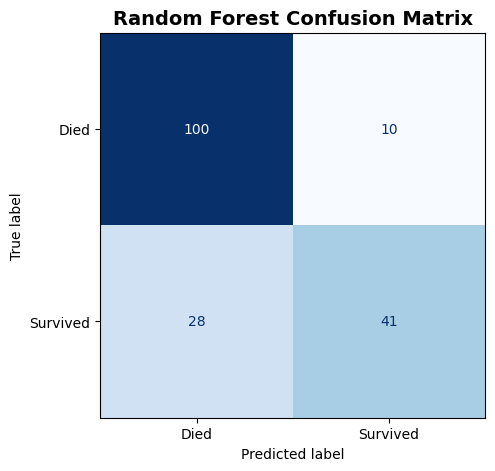

In [7]:
#Plot the Randomm forest confusion matrix
cm_rf=confusion_matrix(y_test,y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_rf,display_labels=['Died','Survived'])
fig,ax=plt.subplots(figsize=(6,5))
disp.plot(cmap='Blues',ax=ax,colorbar=False)
plt.title("Random Forest Confusion Matrix",fontsize=14,fontweight='bold')
plt.grid(False)
plt.show()

In [8]:
#Compare Classifications of different models
classifiers={
    'LogisticRegression':LogisticRegression(max_iter=1000,random_state=42).fit(x_train,y_train),
    'Decision Tree (tuned)': DecisionTreeClassifier(max_depth=best_depth,random_state=42).fit(x_train,y_train),
    'Random Forest': RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42,n_jobs=-1).fit(x_train,y_train)
}

summary=[]
for name,clf in classifiers.items():
    pred=clf.predict(x_test)
    acc=accuracy_score(y_test,pred)
    cv=cross_val_score(clf,x_train,y_train,cv=5,scoring='accuracy').mean()
    summary.append({'Model':name,'Test Accuracy':acc,'CV Accuracy':cv})
summary_df=pd.DataFrame(summary)
print(summary_df)
print("Classifier Performance Comparison:")
print('='*55)
print(summary_df.to_string(index=False))
print('='*55)

                   Model  Test Accuracy  CV Accuracy
0     LogisticRegression       0.804469     0.786556
1  Decision Tree (tuned)       0.810056     0.814705
2          Random Forest       0.787709     0.813287
Classifier Performance Comparison:
                Model  Test Accuracy  CV Accuracy
   LogisticRegression       0.804469     0.786556
Decision Tree (tuned)       0.810056     0.814705
        Random Forest       0.787709     0.813287


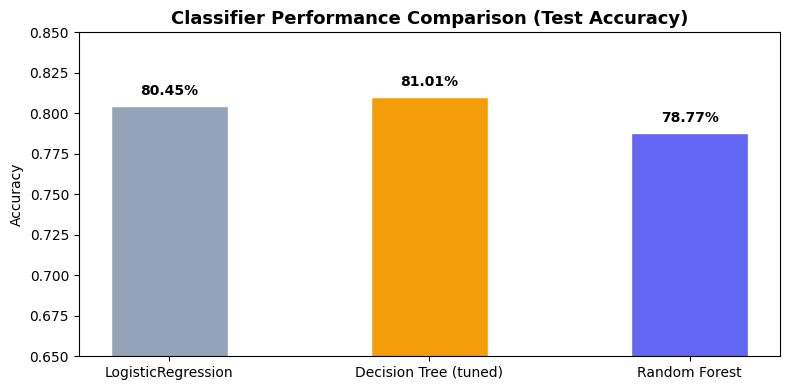

In [9]:
#Make bar plot
plt.figure(figsize=(8,4))
colors=['#94a3b8','#f59e0b','#6366f1']
bars=plt.bar(summary_df['Model'],summary_df['Test Accuracy'],color=colors,width=0.45,edgecolor='white')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
             f'{bar.get_height()*100:.2f}%', ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.title('Classifier Performance Comparison (Test Accuracy)',fontsize=13,fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.65,0.85)
plt.tight_layout()
plt.show()